# 53 Boost Def 3 — XGBoost directo con features completas

Replica exactamente el componente **boost** del notebook `54_hibrido`:

- Mismos **hiperparámetros** hardcodeados (los que dieron R²≈0.818 en sale)
- **Todas las features**: BASE_FEATURES + todos los `municipio_*` OHE del gold
- Eliminación interna de outliers con **IQR×1.5** (igual que 54_hibrido)
- **Sin búsqueda**: no hay Optuna ni GridSearch — entrenamiento directo
- Exporta `XGB_PARAMS_DEF` y `XGB_FEATURES_DEF` para usar en NB54

Tiempo estimado: < 2 minutos

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET_COL   = "log_precio"
CV_FOLDS     = 5
IQR_FACTOR   = 1.5          # misma limpieza interna que 54_hibrido
MIN_MUNI_OBS = 10           # municipios con < N obs → municipio_otros

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


In [12]:
# ── Features base (mismas que 54_hibrido) ─────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "planta_num",
    # "es_exterior_piso",
    # "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Hiperparámetros XGBoost ────────────────────────────────────────────────────
# Idénticos a los hardcodeados en 54_hibrido (los que dan R²≈0.818 en sale).
# Modifica estos valores si dispones de mejores params de Optuna (NB53).
XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print("Configuración:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

Configuración:
  n_estimators: 400
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  reg_lambda: 3
  random_state: 42
  n_jobs: -1
  verbosity: 0


In [13]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = df[TARGET_COL].between(q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr)
    print(f"  Outliers eliminados: {(~mask).sum()} / {len(df)} ({(~mask).mean()*100:.1f}%)")
    return df[mask].copy()


def build_X(df: pd.DataFrame) -> tuple:
    """Construye X con todas las features + municipio_* OHE agrupando raros."""
    df2 = df.copy()

    base = [f for f in BASE_FEATURES if f in df2.columns]

    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []

    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances, feature_names, title, top_n=20):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas originales: 2694
  Outliers eliminados: 0 / 2694 (0.0%)
Filas tras limpieza: 2694
Features (48): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos', 'municipio_Polanco', 'municipio_Ribamontan al Mar

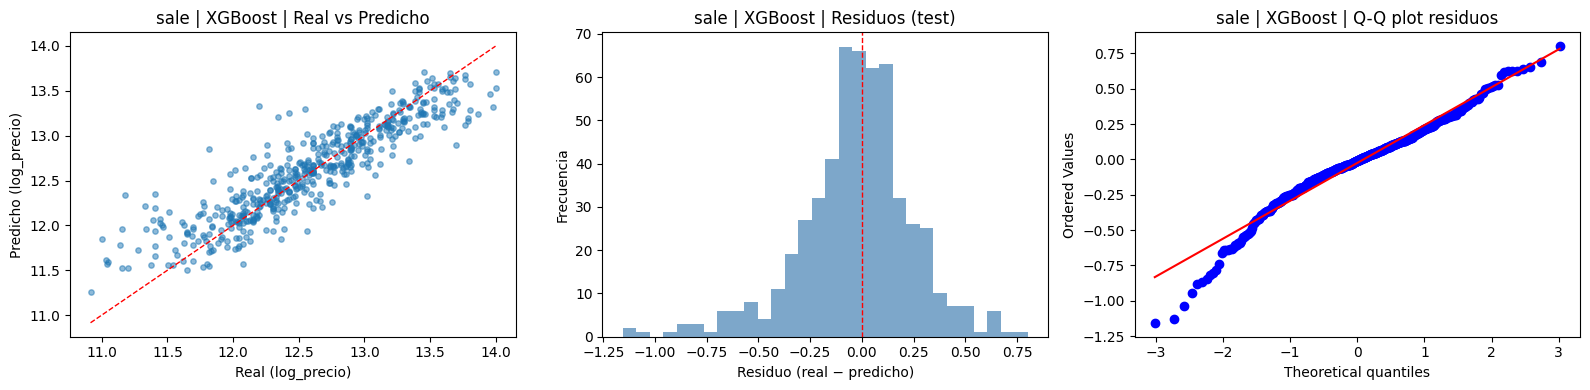

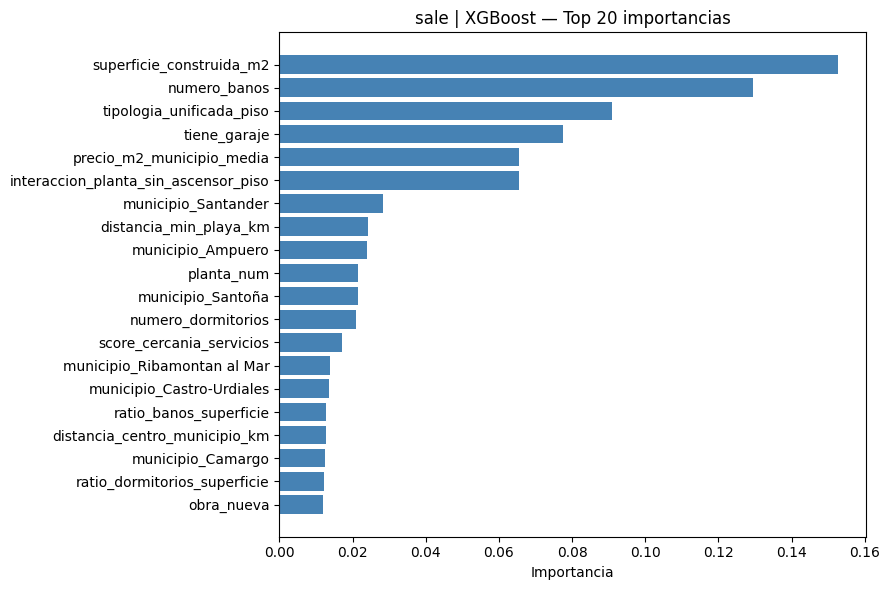


DATASET: RENT
Filas originales: 754
  Outliers eliminados: 0 / 754 (0.0%)
Filas tras limpieza: 754
Features (27): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Laredo', 'municipio_Piélagos', 'municipio_Santa Cruz de Bezana', 'municipio_Santander', 'municipio_Suances', 'municipio_Torrelavega', 'municipio_otro']
Train: 603 | Test: 151

split     MSE    RMSE     MAE      R2    MAPE
train 0.00478 0.06913 0.04921 0.94177 0.00711
   CV     NaN 0.20687     NaN     NaN     NaN
 test 0.04919 0.22180 0.15557 0.460

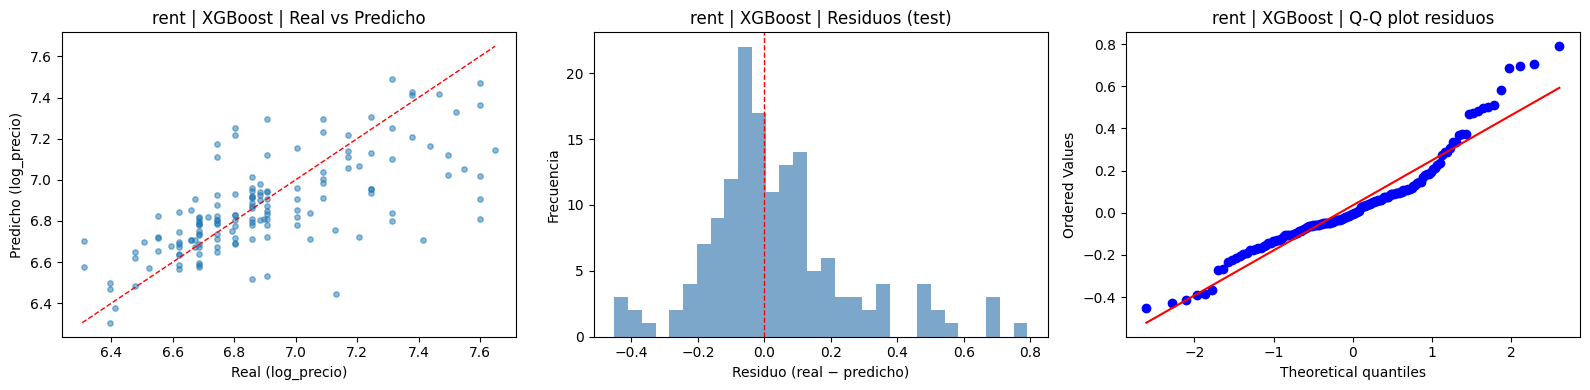

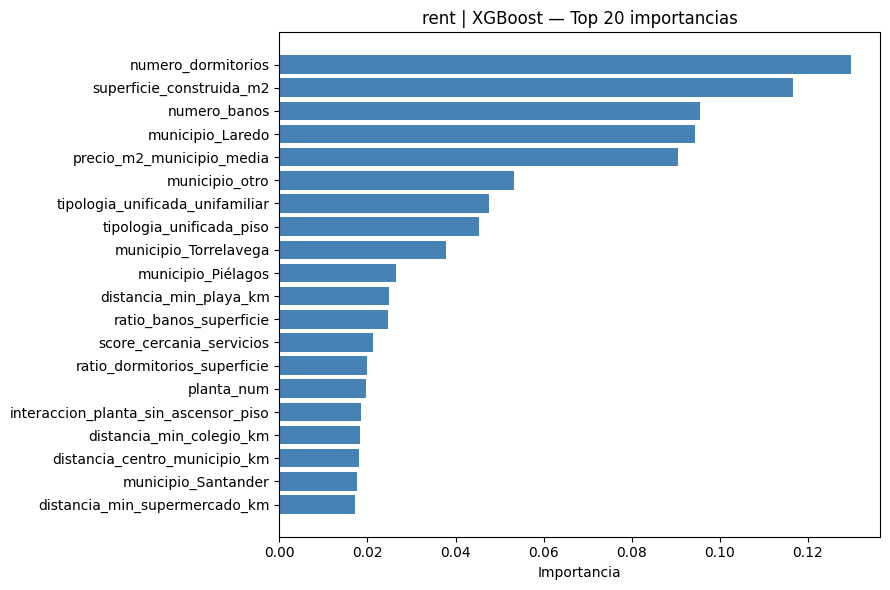


RESUMEN GLOBAL
dataset  n_feats  train_RMSE  cv_RMSE  test_RMSE  train_R2  test_R2
   sale       48     0.18550  0.28462    0.27269   0.89661  0.80443
   rent       27     0.06913  0.20687    0.22180   0.94177  0.46069


In [14]:
# ── Entrenamiento directo — un bloque por dataset ─────────────────────────────

XGB_FEATURES_DEF = {}
XGB_PARAMS_DEF   = {}
all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 90)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 90)

    # ── Carga + limpieza IQR×1.5 (igual que 54_hibrido) ──────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas originales: {len(df)}")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Features completas (BASE + todos los municipio_* OHE) ────────────────
    X, feats = build_X(df)
    y = df[TARGET_COL].values
    print(f"Features ({X.shape[1]}): {feats}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)

    # ── CV-RMSE sobre train ───────────────────────────────────────────────────
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(
        XGBRegressor(**XGB_PARAMS), X_train, y_train,
        cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    cv_rmse = float(-cv_scores.mean())

    # ── Métricas ──────────────────────────────────────────────────────────────
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))

    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None],
                      "RMSE": [round(cv_rmse, 5)],
                      "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(f"\n{summary.to_string(index=False)}")

    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"\n  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")

    plot_diagnostics(y_test, model.predict(X_test), f"{dataset_name} | XGBoost")
    plot_feature_importance(
        model.feature_importances_, feats,
        f"{dataset_name} | XGBoost — Top 20 importancias"
    )

    # ── Guardar para exportar a NB54 ──────────────────────────────────────────
    XGB_FEATURES_DEF[dataset_name] = feats
    XGB_PARAMS_DEF[dataset_name]   = {k: v for k, v in XGB_PARAMS.items()
                                       if k not in ("random_state", "n_jobs", "verbosity")}

    all_summary_rows.append({
        "dataset":   dataset_name,
        "n_feats":   X.shape[1],
        "train_RMSE": float(m_train["RMSE"].iloc[0]),
        "cv_RMSE":    cv_rmse,
        "test_RMSE":  float(m_test["RMSE"].iloc[0]),
        "train_R2":   float(m_train["R2"].iloc[0]),
        "test_R2":    float(m_test["R2"].iloc[0]),
    })

print()
print("=" * 90)
print("RESUMEN GLOBAL")
print("=" * 90)
print(pd.DataFrame(all_summary_rows).round(5).to_string(index=False))

In [15]:
# ── Exportar para NB54 ────────────────────────────────────────────────────────
print("=" * 90)
print("RESUMEN PARA NB54 — copiar XGB_PARAMS_DEF y XGB_FEATURES_DEF:")
print("=" * 90)
for ds in XGB_PARAMS_DEF:
    print(f"\n  # {ds.upper()}")
    print(f"  XGB_PARAMS_DEF['{ds}']   = {XGB_PARAMS_DEF[ds]}")
    print(f"  XGB_FEATURES_DEF['{ds}'] = {XGB_FEATURES_DEF[ds]}")

RESUMEN PARA NB54 — copiar XGB_PARAMS_DEF y XGB_FEATURES_DEF:

  # SALE
  XGB_PARAMS_DEF['sale']   = {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_lambda': 3}
  XGB_FEATURES_DEF['sale'] = ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cud